In [1]:
import pandas as pd

print(pd.__version__)


3.0.3


In [2]:
cpi = pd.read_csv("C:/Users/novin/Documents/Project/Inflation_analysis/cpi.csv")
rate = pd.read_csv("C:/Users/novin/Documents/Project/Inflation_analysis/interest_rate.csv")

In [3]:
p=cpi.head()

In [4]:
print(p)

  observation_date  CPIAUCSL
0       1947-01-01     21.48
1       1947-02-01     21.62
2       1947-03-01     22.00
3       1947-04-01     22.00
4       1947-05-01     21.95


In [5]:
cpi.rename(columns={"observation_date": "DATE"}, inplace=True)
rate.rename(columns={"observation_date": "DATE"}, inplace=True)



In [6]:
print(cpi.head())
print(rate.head())


         DATE  CPIAUCSL
0  1947-01-01     21.48
1  1947-02-01     21.62
2  1947-03-01     22.00
3  1947-04-01     22.00
4  1947-05-01     21.95
         DATE  FEDFUNDS
0  1954-07-01      0.80
1  1954-08-01      1.22
2  1954-09-01      1.07
3  1954-10-01      0.85
4  1954-11-01      0.83


In [7]:

cpi["DATE"] = pd.to_datetime(cpi["DATE"])
rate["DATE"] = pd.to_datetime(rate["DATE"])

In [8]:
cpi = cpi.set_index("DATE")
rate = rate.set_index("DATE")


In [9]:
cpi["inflation"] = cpi["CPIAUCSL"].pct_change(12) * 100


import  matplotlib
import  numpy as np
plt.figure(figsize=(12,5))

cpi["inflation"].plot()

plt.title("US Inflation Rate (YoY)")
plt.ylabel("Percent")
plt.xlabel("Year")

plt.show()


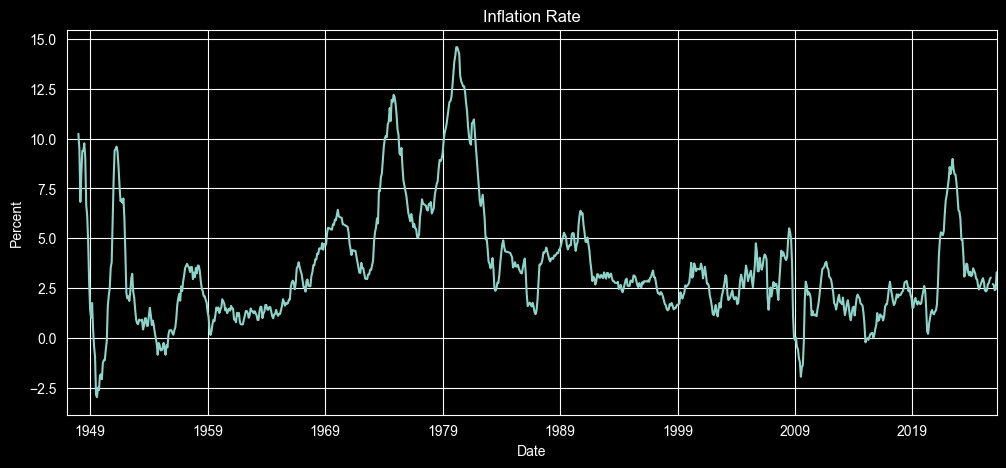

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,5))

cpi["inflation"].plot()

plt.title("Inflation Rate")
plt.xlabel("Date")
plt.ylabel("Percent")

plt.show()


In [11]:
data = cpi.join(rate)
data.head()


,CPIAUCSL,inflation,FEDFUNDS
DATE,,,
1947-01-01,21.48,NaN,NaN
1947-02-01,21.62,NaN,NaN
1947-03-01,22.00,NaN,NaN
1947-04-01,22.00,NaN,NaN
1947-05-01,21.95,NaN,NaN


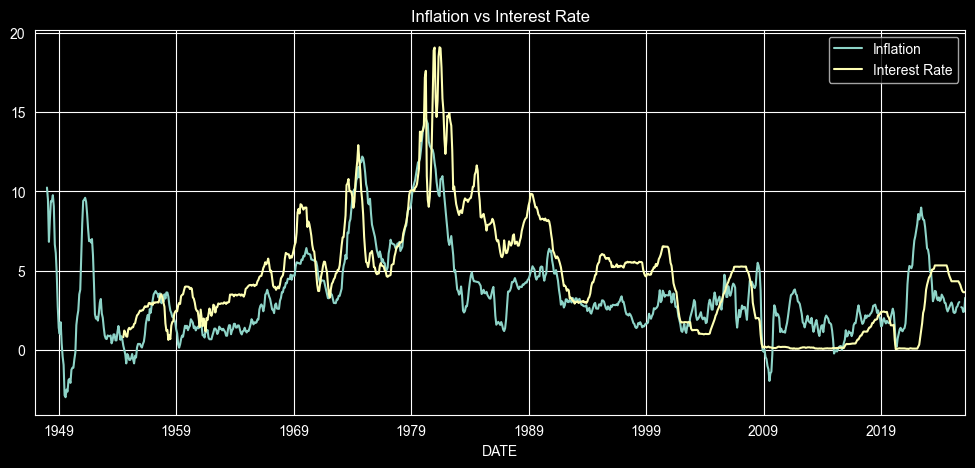

In [12]:
plt.figure(figsize=(12,5))

data["inflation"].plot(label="Inflation")
data["FEDFUNDS"].plot(label="Interest Rate")

plt.legend()
plt.title("Inflation vs Interest Rate")

plt.show()


In [13]:
mahasebeh=data[["inflation","FEDFUNDS"]].corr()


In [14]:
print(mahasebeh)

           inflation  FEDFUNDS
inflation   1.000000  0.708358
FEDFUNDS    0.708358  1.000000


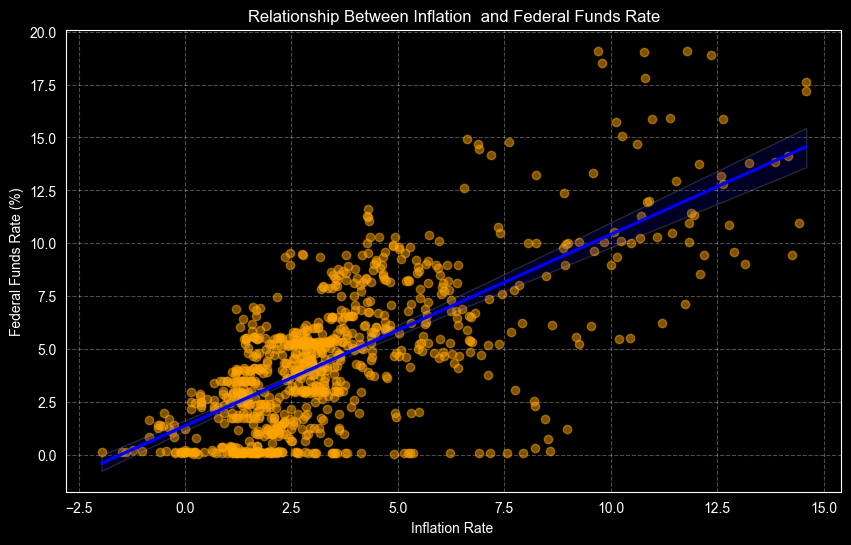

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge CPI and FEDFUNDS into one dataframe (if not already merged)
# Make sure both have 'inflation' and 'FEDFUNDS'
df = data.dropna(subset=["inflation", "FEDFUNDS"])

plt.figure(figsize=(10,6))
sns.regplot(
    x=df["inflation"],
    y=df["FEDFUNDS"],
    scatter_kws={"alpha": 0.5, "color": "orange"},
    line_kws={"color": "blue"}
)

plt.title("Relationship Between Inflation  and Federal Funds Rate")
plt.xlabel("Inflation Rate ")
plt.ylabel("Federal Funds Rate (%)")
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()
# The scatter plot with a regression line shows a clear positive relationship
# between year-over-year inflation and the Federal Funds Rate.
# Periods of higher inflation are generally associated with higher interest rates,
# reflecting the Federal Reserve's monetary policy response to rising prices.



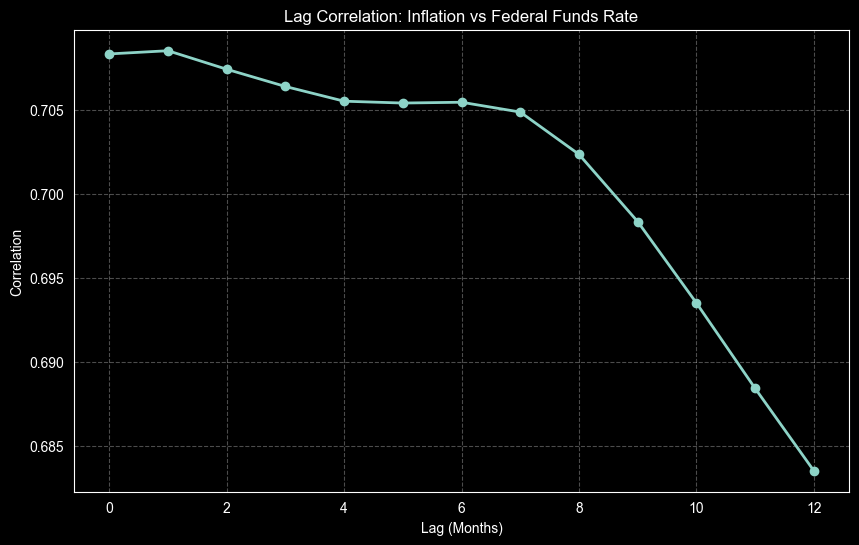

In [16]:

# Federal Reserve Response to Inflation Dynamics

### Analyzing the Time Lag Between Inflation Increases and Federal Reserve Interest Rate Decisions
import pandas as pd
import matplotlib.pyplot as plt

# Create lagged inflation variables
lags = range(0, 13)

correlations = []

for lag in lags:

    corr = data["inflation"].shift(lag).corr(data["FEDFUNDS"])

    correlations.append(corr)

# Plot
plt.figure(figsize=(10,6))

plt.plot(lags, correlations, marker="o", linewidth=2)

plt.title("Lag Correlation: Inflation vs Federal Funds Rate")
plt.xlabel("Lag (Months)")
plt.ylabel("Correlation")

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()
#The lag correlation results show that the strongest relationship between
#inflation and the Federal Funds Rate occurs at lag 0 and lag 1. This indicates
#that the Federal Reserve reacts very quickly to changes in inflation, typically
#within the same month or the following month. At longer lags, the correlation
#weakens substantially, suggesting that older inflation data has little influence
#on current monetary policy decisions.



<h1 style="color:darkblue;">
Federal Reserve Response to Inflation
</h1>

<h3 style="color:darkred;">
How Many Months After Rising Inflation Does the Federal Reserve React?
</h3>


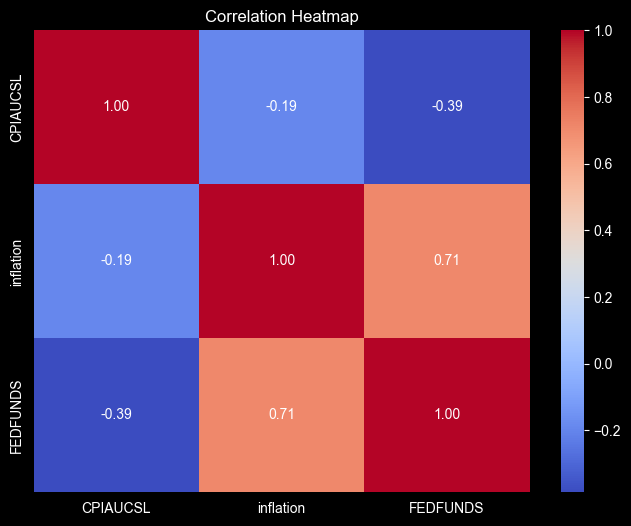

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['CPIAUCSL', 'inflation', 'FEDFUNDS']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()
#Interest rates respond primarily to inflation rather than to the absolute level of prices.
#Consequently, the correlation between inflation and the Federal Funds Rate is strong and positive,
#whereas the relationship between CPI levels and interest rates is weaker and less stable.


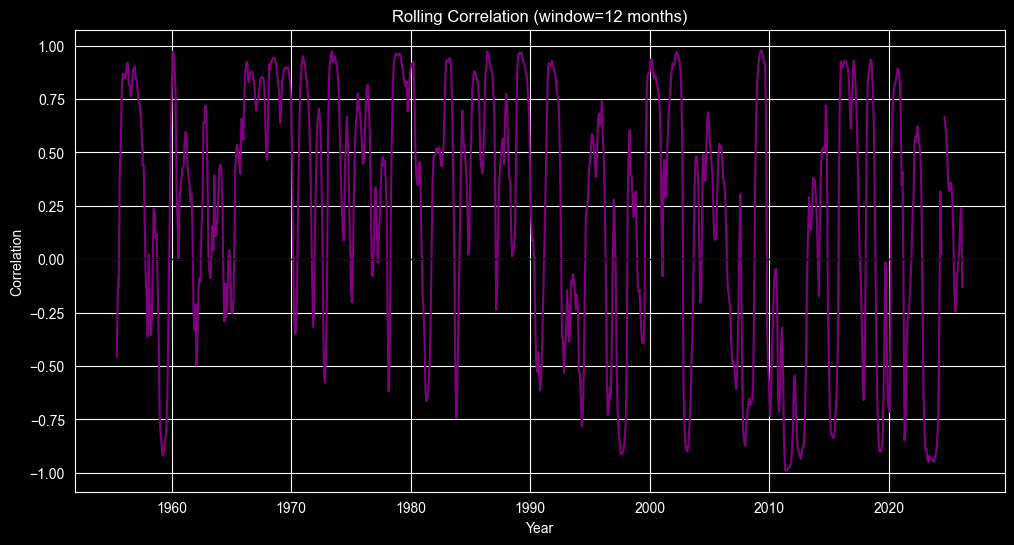

In [18]:
window = 12  # 12 months rolling window

rolling_corr = df['inflation'].rolling(window).corr(df['FEDFUNDS'])

plt.figure(figsize=(12,6))
plt.plot(df.index, rolling_corr, color='purple')
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Rolling Correlation (window={window} months)')
plt.xlabel('Year')
plt.ylabel('Correlation')
plt.show()


In [19]:
#forcast inflation with ARIMA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller


In [20]:
result = adfuller(data['inflation'].dropna())

print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -3.8004636697453607
p-value: 0.002902574606447659


In [21]:
model = ARIMA(data['inflation'], order=(1,0,1))
model_fit = model.fit()


print(model_fit.summary())
# =============================================================================
# تحلیل نهایی نتایج ARIMA:
# -----------------------------------------------------------------------------
# 1. تست Ljung-Box (p-value=0.18): باقی‌مانده‌ها دارای خودهمبستگی نیستند (نویز سفید)،
#    که نشان‌دهنده موفقیت مدل در جذب ساختار زمانی تورم است.
#
# 2. تست Jarque-Bera (p-value=0.00): خطاها دارای توزیع غیرنرمال هستند که در داده‌های
#    اقتصاد کلان ایران به دلیل شوک‌های ساختاری، کاملاً طبیعی است.
#
# 3. تست Heteroskedasticity (p-value=0.00): وجود ناهمسانی واریانس تایید شد. این یعنی
#    نوسانات تورم (Volatility) دارای خوشه‌بندی است و پیشنهاد می‌شود در مدل‌های بعدی
#    از ساختار GARCH برای مدل‌سازی نوسانات استفاده شود.
# =============================================================================


C:\Users\novin\Documents\Project\Inflation_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\novin\Documents\Project\Inflation_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\novin\Documents\Project\Inflation_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              inflation   No. Observations:                  951
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -502.814
Date:                Sat, 23 May 2026   AIC                           1013.627
Time:                        11:37:44   BIC                           1033.057
Sample:                    01-01-1947   HQIC                          1021.030
                         - 03-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8704      0.916      4.227      0.000       2.076       5.665
ar.L1          0.9822      0.005    190.483      0.000       0.972       0.992
ma.L1          0.3658      0.018     20.308      0.0

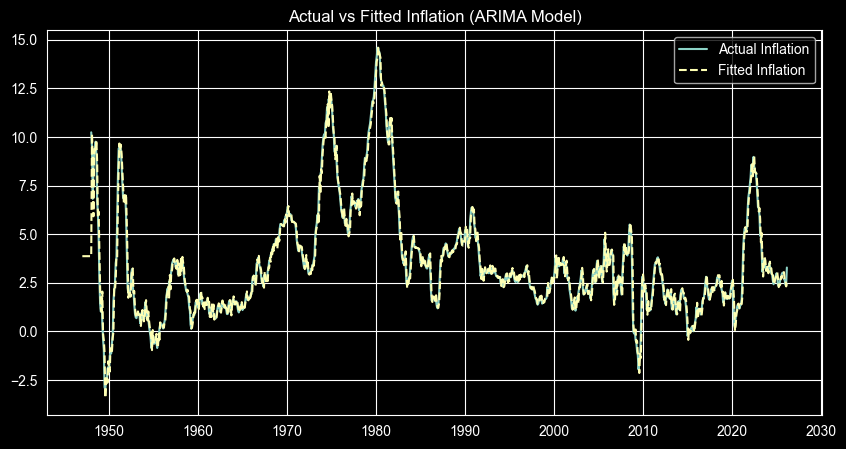

In [22]:
# استخراج مقادیر پیش‌بینی شده توسط مدل
fitted_values = model_fit.fittedvalues

# رسم نمودار
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# داده واقعی
plt.plot(data["inflation"], label='Actual Inflation')

# مقدار برازش شده توسط مدل
plt.plot(fitted_values, label='Fitted Inflation', linestyle='--')

plt.title('Actual vs Fitted Inflation (ARIMA Model)')
plt.legend()

plt.show()


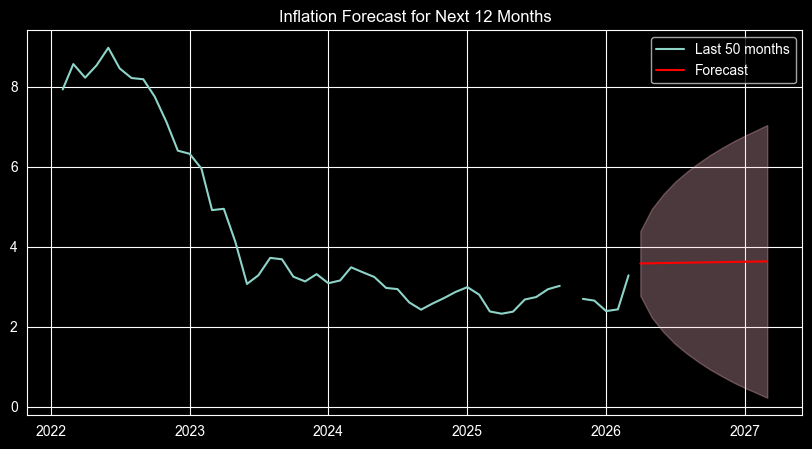

In [23]:
# پیش‌بینی برای ۱۲ ماه آینده
forecast = model_fit.get_forecast(steps=12)
forecast_df = forecast.summary_frame()

# رسم نمودار پیش‌بینی
plt.figure(figsize=(10, 5))
plt.plot(data['inflation'].tail(50), label='Last 50 months') # نمایش ۵۰ ماه آخر برای وضوح بیشتر
plt.plot(forecast_df['mean'], label='Forecast', color='red')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('Inflation Forecast for Next 12 Months')
plt.legend()
plt.show()


In [27]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

# ۱. پاکسازی داده‌ها از مقادیر خالی (NaN)
data = data.dropna(subset=['inflation'])

# ۲. تقسیم داده‌ها بر اساس متغیر data
train_size = len(data) - 5
train = data['inflation'].iloc[:train_size]
test = data['inflation'].iloc[train_size:]

# ۳. آماده‌سازی برای پیش‌بینی
history = [x for x in train]
predictions = []

# ۴. پیش‌بینی گام به گام (Walk-forward validation)
for t in range(len(test)):
    model = ARIMA(history, order=(1, 0, 1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)

    obs = test.iloc[t]
    history.append(obs)
    print(f'ماه {t+1}: پیش‌بینی={yhat:.2f}, واقعی={obs:.2f}')

# ۵. محاسبه خطا (RMSE)
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f'\n====================================')
print(f'خطای کل مدل (RMSE): {rmse:.3f}')
print(f'====================================')


ماه 1: پیش‌بینی=3.04, واقعی=2.70
ماه 2: پیش‌بینی=2.59, واقعی=2.65
ماه 3: پیش‌بینی=2.70, واقعی=2.39
ماه 4: پیش‌بینی=2.30, واقعی=2.43
ماه 5: پیش‌بینی=2.51, واقعی=3.29

خطای کل مدل (RMSE): 0.409


C:\Users\novin\Documents\Project\Inflation_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\novin\Documents\Project\Inflation_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\novin\Documents\Project\Inflation_analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


نتیجه آزمون اثرات ARCH:
P-value: 0.0000

نتیجه: P-value کمتر از ۰.۰۵ است.
تبریک! اثرات ARCH در داده‌های شما وجود دارد.
مدل GARCH می‌تواند دقت پیش‌بینی شما را به‌طور قابل‌توجهی بهبود دهد.


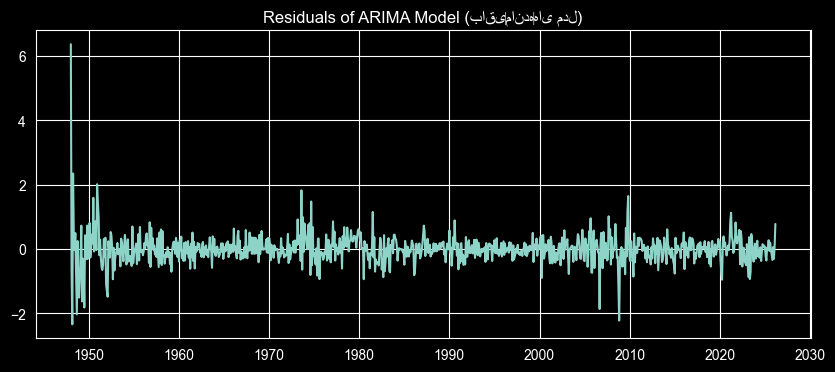

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch

# ۱. برازش مدل ARIMA روی کل داده‌ها (برای استخراج Residuals)
# از همان مرتبه (1,0,1) که قبلاً داشتی استفاده می‌کنیم
model = ARIMA(data['inflation'], order=(1, 0, 1))
model_fit = model.fit()

# ۲. استخراج باقی‌مانده‌ها (Residuals)
residuals = model_fit.resid

# ۳. بررسی آماری وجود اثرات ARCH
# آزمون Engle's ARCH test بررسی می‌کند که آیا واریانس خطاها تصادفی است یا الگو دارد
test_stat, p_value, f_stat, f_p_value = het_arch(residuals)

print(f'نتیجه آزمون اثرات ARCH:')
print(f'P-value: {p_value:.4f}')

if p_value < 0.05:
    print("\nنتیجه: P-value کمتر از ۰.۰۵ است.")
    print("تبریک! اثرات ARCH در داده‌های شما وجود دارد.")
    print("مدل GARCH می‌تواند دقت پیش‌بینی شما را به‌طور قابل‌توجهی بهبود دهد.")
else:
    print("\nنتیجه: P-value بزرگتر از ۰.۰۵ است.")
    print("اثرات ARCH معنادار نیستند. مدل ARIMA به تنهایی کافی است و GARCH بهبود خاصی ایجاد نمی‌کند.")

# ۴. نمایش بصری Residualها
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title('Residuals of ARIMA Model (باقی‌مانده‌های مدل)')
plt.show()
# P-value برابر با 0.0000 به این معنی است که «اثرات ARCH» به شدت در داده‌ها وجود دارد.


                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -360.450
Distribution:                  Normal   AIC:                           728.901
Method:            Maximum Likelihood   BIC:                           748.276
                                        No. Observations:                  938
Date:                Sat, May 23 2026   Df Residuals:                      937
Time:                        12:08:26   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu            -0.0120  1.045e-02     -1.144      0.253 

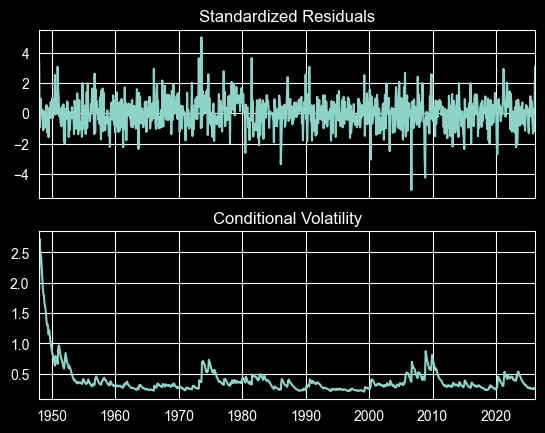

In [30]:
#کد مدل سازی نوسانات
from arch import arch_model

# تعریف مدل GARCH
# p=1, q=1 یعنی نوسان امروز وابسته به نوسان دیروز و خطای دیروز است
garch_model = arch_model(residuals, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp='off')

# نمایش خلاصه وضعیت مدل
print(garch_result.summary())

# رسم نمودار نوسانات پیش‌بینی شده
garch_result.plot()
plt.show()


In [31]:
# از آنجایی که قبلاً مدل ARIMA و GARCH را داشتیم، حالا ترکیبشان می‌کنیم:
# در کتابخانه arch، می‌توانیم مستقیماً مدل را به شکل زیر تعریف کنیم:

model = arch_model(data['inflation'].dropna(),
                   mean='AR',  # استفاده از AR برای بخش میانگین
                   lags=1,     # تعداد وقفه برای بخش AR (بر اساس مدل ARIMA قبلی شما)
                   vol='Garch',
                   p=1, q=1)   # مدل GARCH(1,1)

# برازش مدل ترکیبی
results = model.fit(disp='off')

# نمایش خلاصه
print(results.summary())

# پیش‌بینی برای 12 ماه آینده
forecasts = results.forecast(horizon=12)

# نمایش نتایج پیش‌بینی میانگین و واریانس
print(forecasts.mean.iloc[-1])
print(forecasts.variance.iloc[-1])


                           AR - GARCH Model Results                           
Dep. Variable:              inflation   R-squared:                       0.976
Mean Model:                        AR   Adj. R-squared:                  0.976
Vol Model:                      GARCH   Log-Likelihood:               -392.766
Distribution:                  Normal   AIC:                           795.533
Method:            Maximum Likelihood   BIC:                           819.746
                                        No. Observations:                  937
Date:                Sat, May 23 2026   Df Residuals:                      935
Time:                        12:14:24   Df Model:                            2
                                   Mean Model                                  
                   coef    std err          t      P>|t|       95.0% Conf. Int.
-------------------------------------------------------------------------------
Const            0.0338  2.120e-02      1.594    

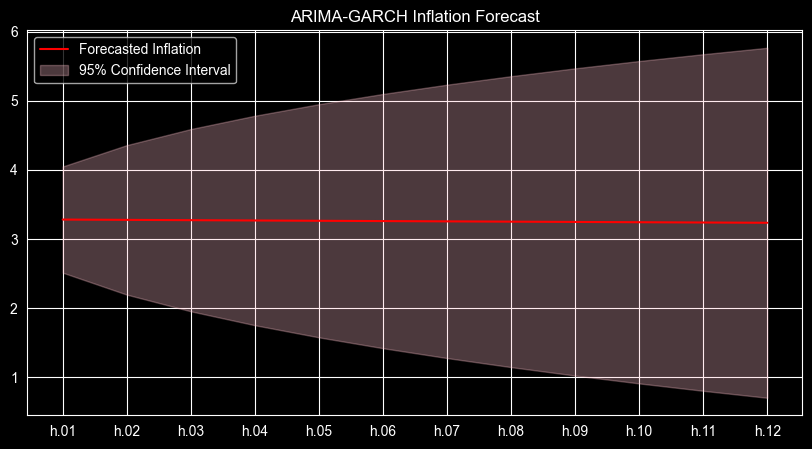

In [32]:
import matplotlib.pyplot as plt

# دریافت پیش‌بینی‌ها
forecasts = results.forecast(horizon=12)
mean_forecast = forecasts.mean.iloc[-1]
# واریانس پیش‌بینی (مجذور آن می‌شود انحراف معیار یا همان خطای استاندارد)
std_dev = forecasts.variance.iloc[-1]**0.5

plt.figure(figsize=(10, 5))
plt.plot(mean_forecast, label='Forecasted Inflation', color='red')
# رسم بازه اطمینان (میانگین +- ۲ برابرِ انحراف معیار)
plt.fill_between(mean_forecast.index,
                 mean_forecast - 1.96 * std_dev,
                 mean_forecast + 1.96 * std_dev,
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('ARIMA-GARCH Inflation Forecast')
plt.legend()
plt.show()
